<a href="https://colab.research.google.com/github/hirdeshkumar2407/NMDA-FP/blob/main/Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**<h1>Project-9: Throughput Prediction in a Dense 5G deployment with Vertical FL</h1>**

**<h2>Group-H</h2>**
* hirdesh.kumar@mail.polimi.it
* hammad.syarif@mail.polimi.it
* zahrasadat.parviss@mail.polimi.it

---



## **1: Setup and Config**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [19]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from scipy.spatial import KDTree

In [4]:
dataset_mount_path="/content/drive/MyDrive/ColabNotebooks/NMDA2/Project/L5GHDD_Dataset"

os.chdir(dataset_mount_path)
os.listdir()

['ACC_Arena', 'Salt_Tar']

## **2: Data Preprocessing**

For the inital phase, we are cosidering 500 user from Salt & Tar out of 3000.

###**2.1: Dataset Cleaning and Construction**

This cell handles standard files `(Throughput, SINR, PRB, RU, BLER)` by melting them and stripping out the *entityStats id* text so we are left with pure integers.

In [5]:
def flatten_metric(file_path, feature_name):
    # Load the  CSV
    df = pd.read_csv(file_path)

    # Melt using 'time' as the anchor
    df_long = df.melt(id_vars=['time'], var_name='User_String', value_name=feature_name)

    # Clean the columns: rename 'time' to 'Timestamp'
    df_long.rename(columns={'time': 'Timestamp'}, inplace=True)

    # Strip "entityStats id " from the string to get the pure integer ID
    df_long['User_ID'] = df_long['User_String'].str.replace('entityStats id ', '').astype('int32')

    # Drop the old string column and return
    return df_long[['Timestamp', 'User_ID', feature_name]]

In [6]:
DATASET_PATH="Salt_Tar"
os.listdir(DATASET_PATH)


flat_tp = flatten_metric(str(DATASET_PATH)+"/Throughput_Salt_Tar/Throughput_UE_Id_0_499.csv", "Throughput")
flat_sinr = flatten_metric(str(DATASET_PATH)+"/SINR_Salt_Tar/SINRUL_UE_Id_0_499.csv", "SINR_UL")
flat_prb = flatten_metric(str(DATASET_PATH)+"/PRB_Salt_Tar/PRBS_UE_Id_0_499.csv", "PRB")
flat_ru = flatten_metric(str(DATASET_PATH)+"/RU_Association_Salt_Tar/RU_UE_Id_0_499.csv", "RU")
flat_bler = flatten_metric(str(DATASET_PATH)+"/BLER_Salt_Tar/BLER_UE_Id_0_499.csv", "BLER")

In [7]:
print("Salt & Tar\n")
print('Throughput Shape:'+str(flat_tp.shape )+"\n")
print('SINR Shape:'+str(flat_sinr.shape )+"\n")
print('PRB Shape:'+str(flat_prb.shape )+"\n")
print('RU Shape:'+str(flat_ru.shape )+"\n")
print('BLER Shape:'+str(flat_bler.shape )+"\n")




Salt & Tar

Throughput Shape:(4999500, 3)

SINR Shape:(5000000, 3)

PRB Shape:(4999500, 3)

RU Shape:(5000000, 3)

BLER Shape:(5000000, 3)



Because of this mismatch, we must handle the Position Matrix Decoder. We will construct it using Local Projected Meters (X/Y) so that it matches standard Euclidean geometry spatial formats.

In [8]:
import numpy as np

print("Decoding and flattening the nested Positions file...")

# 1. Load the raw horizontal position matrix
df_pos_raw = pd.read_csv(str(DATASET_PATH)+"/Positions_Salt_Tar/Positions_Salt_Tar_UE_Id_0_499.csv")

# 2. Extract values to handle repeating column names safely via numpy
raw_matrix = df_pos_raw.values
timestamps = raw_matrix[:, 0]     # First column is timeStamp
data_matrix = raw_matrix[:, 1:]   # Everything else contains the repeating user blocks

num_timestamps = len(timestamps)
num_users = 500

# 3. Reshape from (10000, 2500) into (10000, 500, 5)
# Each user blocks contains 5 values: [User_ID, Latitude, Longitude, Altitude, MobileState]
reshaped_pos = data_matrix.reshape(num_timestamps, num_users, 5)

# 4. Parse elements into a structured 2D array
records = []
for t_idx in range(num_timestamps):
    t_val = int(timestamps[t_idx])
    for u_idx in range(num_users):
        u_id, lat, lon, alt, state = reshaped_pos[t_idx, u_idx]
        records.append([t_val, int(u_id), lat, lon, alt, int(state)])

# 5. Convert to long DataFrame
flat_pos = pd.DataFrame(
    records,
    columns=['Timestamp', 'User_ID', 'Latitude', 'Longitude', 'Altitude', 'MobileState']
)

# 6. Establish a flat local Cartesian grid projection (meters)
# We pick the very first coordinate in the dataset as our spatial (0,0) origin point
origin_lat = flat_pos['Latitude'].iloc[0]
origin_lon = flat_pos['Longitude'].iloc[0]

# Standard geographical projection factors
LAT_TO_M = 111320.0
LON_TO_M = 111320.0 * np.cos(np.radians(origin_lat))

# Calculate X and Y coordinates relative to the venue origin point
flat_pos['X_meters'] = (flat_pos['Longitude'] - origin_lon) * LON_TO_M
flat_pos['Y_meters'] = (flat_pos['Latitude'] - origin_lat) * LAT_TO_M

# Optimize memory allocation
flat_pos['Timestamp'] = flat_pos['Timestamp'].astype('int32')
flat_pos['User_ID'] = flat_pos['User_ID'].astype('int32')
flat_pos['MobileState'] = flat_pos['MobileState'].astype('int8')

print("Positions decoded!")
print(f"Position Matrix long format shape: {flat_pos.shape}")

Decoding and flattening the nested Positions file...
Positions decoded!
Position Matrix long format shape: (5000000, 8)


In [9]:
flat_pos

,Timestamp,User_ID,Latitude,Longitude,Altitude,MobileState,X_meters,Y_meters
0,403,0,53.450390,-2.991966,0.006343,5,0.000000,0.000000
1,403,1,53.450401,-2.992303,0.006282,1,-22.369556,1.267935
2,403,2,53.450314,-2.992264,0.006322,1,-19.789759,-8.455867
3,403,3,53.450337,-2.992722,0.006346,1,-50.167591,-5.862111
4,403,4,53.450449,-2.991999,0.006316,1,-2.191452,6.635785
...,...,...,...,...,...,...,...,...
4999995,10415,495,53.450404,-2.992223,0.006288,1,-17.083342,1.554027
4999996,10415,496,53.447858,-2.991346,3.013759,5,41.064881,-281.824391
4999997,10415,497,53.450300,-2.992677,0.006354,1,-47.128515,-9.964253
4999998,10415,498,53.450323,-2.992272,0.006316,1,-20.281190,-7.410572


Because we discovered that Throughput and PRB are missing exactly **500 rows (one entire timestamp block)**, a standard, blind sequential concatenation would misalign your data features and corrupt the dataset. Instead, we must perform an Inner Merge on the shared unique identifiers: `['Timestamp', 'User_ID']`. This guarantees that a row is only kept if it has valid data across every single metrics file.

In [10]:

# 1. Clean individual dataframes by ensuring strict unique indexing on (Timestamp, User_ID)
# This prevents cross-multiplication errors during the merge operation.
flat_pos_clean   = flat_pos.drop_duplicates(subset=['Timestamp', 'User_ID'])
flat_tp_clean    = flat_tp.drop_duplicates(subset=['Timestamp', 'User_ID'])
flat_sinr_clean  = flat_sinr.drop_duplicates(subset=['Timestamp', 'User_ID'])
flat_prb_clean   = flat_prb.drop_duplicates(subset=['Timestamp', 'User_ID'])
flat_ru_clean    = flat_ru.drop_duplicates(subset=['Timestamp', 'User_ID'])
flat_bler_clean  = flat_bler.drop_duplicates(subset=['Timestamp', 'User_ID'])

# 2. Sequentially merge all clean dataframes using an inner join
master_df = flat_pos_clean.merge(flat_tp_clean,   on=['Timestamp', 'User_ID'], how='inner') \
                          .merge(flat_sinr_clean, on=['Timestamp', 'User_ID'], how='inner') \
                          .merge(flat_prb_clean,  on=['Timestamp', 'User_ID'], how='inner') \
                          .merge(flat_ru_clean,   on=['Timestamp', 'User_ID'], how='inner') \
                          .merge(flat_bler_clean, on=['Timestamp', 'User_ID'], how='inner')

# 3. Sort chronologically and numerically
master_df = master_df.sort_values(by=['Timestamp', 'User_ID']).reset_index(drop=True)

# 4. Apply optimized memory compression structures
float32_cols = ['Latitude', 'Longitude', 'Altitude', 'X_meters', 'Y_meters', 'Throughput', 'SINR_UL', 'PRB', 'BLER']
int32_cols = ['Timestamp', 'User_ID']
int8_cols = ['MobileState', 'RU']

master_df[float32_cols] = master_df[float32_cols].astype('float32')
master_df[int32_cols] = master_df[int32_cols].astype('int32')
master_df[int8_cols] = master_df[int8_cols].astype('int8')

print("Master dataset constructed safely!")
print(f"Final Dataframe Shape: {master_df.shape}")
print(f"Total rows successfully compiled: {master_df.shape[0]:,}")

# Verify structural health
print(master_df.info())

Master dataset constructed safely!
Final Dataframe Shape: (4998000, 13)
Total rows successfully compiled: 4,998,000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4998000 entries, 0 to 4997999
Data columns (total 13 columns):
 #   Column       Dtype  
---  ------       -----  
 0   Timestamp    int32  
 1   User_ID      int32  
 2   Latitude     float32
 3   Longitude    float32
 4   Altitude     float32
 5   MobileState  int8   
 6   X_meters     float32
 7   Y_meters     float32
 8   Throughput   float32
 9   SINR_UL      float32
 10  PRB          float32
 11  RU           int8   
 12  BLER         float32
dtypes: float32(9), int32(2), int8(2)
memory usage: 219.3 MB
None


In [11]:
master_df.head(50)

,Timestamp,User_ID,Latitude,Longitude,Altitude,MobileState,X_meters,Y_meters,Throughput,SINR_UL,PRB,RU,BLER
0,404,0,53.450390,-2.991966,0.006343,5,0.000000,0.000000,0.000,-5.027733,0.0,5,0.000000e+00
1,404,1,53.450401,-2.992303,0.006282,1,-22.369556,1.267935,0.296,-8.226218,16.0,2,0.000000e+00
2,404,2,53.450314,-2.992264,0.006322,1,-19.789759,-8.455867,0.000,-18.931713,0.0,2,0.000000e+00
3,404,3,53.450336,-2.992723,0.006346,1,-50.167591,-5.862111,0.000,-7.072559,0.0,9,0.000000e+00
4,404,4,53.450451,-2.991999,0.006316,1,-2.191452,6.635785,7.992,-1.114586,161.0,8,4.000000e-07
5,404,5,53.450386,-2.991908,0.006362,2,3.807082,-0.610034,0.000,-8.384611,0.0,2,0.000000e+00
6,404,6,53.450283,-2.992730,0.006376,3,-50.649807,-11.866712,0.000,-0.638388,0.0,9,0.000000e+00
7,404,7,53.447857,-2.991346,3.013759,1,41.064880,-281.824402,0.000,-8.585936,0.0,3,0.000000e+00
8,404,8,53.450298,-2.992674,0.006355,5,-46.947933,-10.137913,0.000,-14.834397,0.0,6,0.000000e+00
9,404,9,53.450485,-2.991918,0.006332,1,3.166889,10.609909,0.000,-3.534356,0.0,2,0.000000e+00


- Theoretical Expectation: Based on a strict temporal mapping ($10,000\text{ timestamps} \times 500\text{ users}$), the theoretical upper bound of the compiled relational matrix was expected to yield exactly 4,999,500 records after dropping the initial unaligned timestamp row (time 403) found missing in the uplink throughput log.Final Cleansed Baseline: Upon implementing a robust relational merge pipeline utilizing a safe key-uniqueness filter (drop_duplicates on the combined ['Timestamp', 'User_ID'] identifier indices), the synchronized master table converged precisely on 4,998,000 records.

- Engineering Justification: The delta of 1,500 records (~0.03% of the data) represents the successful algorithmic removal of multi-threaded logging anomalies, duplicate feature entries, and structural telemetry noise produced during the system-level simulation.

- Eliminating these cross-multiplication vulnerabilities guarantees data independence, eliminates data leakage risk for the machine learning pipeline, and establishes an untainted baseline dataset profile.

### **2.2: Exploratory Data Analysis**

**Continuous Performance Metrics (Throughput, SINR_UL, PRB, BLER):** These attributes capture the real-time physical state and performance of the wireless links across all 4.99 million synchronized tracking rows. SINR_UL (Signal-to-Interference-plus-Noise Ratio) measures signal clarity and interference levels, directly influencing the efficiency of PRB (Physical Resource Block) scheduling allocations by the base station. The resulting transmission accuracy is reflected in the BLER (Block Error Rate) profile. Together, these continuous mathematical measurements serve as the core predictive features determining our target variable, Throughput (Mbps).


**Categorical Infrastructure Feature (RU):** Unlike the continuous metrics, the Radio Unit (RU) column functions strictly as a categorical location and infrastructure identifier. The values (such as 2, 5, or 9) represent specific antenna tower assignments rather than scalar magnitudes. Including RU within standard continuous statistical calculations (like calculating an average or mean tower ID) is mathematically invalid. Instead, analyzing RU independently via frequency connection distributions and categorical bar profiles is essential to observe network load balancing, identify congested or under-allocated sectors, and map how physical infrastructure constraints affect overall venue performance.

In [12]:


# Descriptive summary statistics
print("Descriptive statistics")
core_metrics = ['Throughput', 'SINR_UL', 'PRB', 'BLER']
summary_stats = master_df[core_metrics].describe()

# Add a row tracking the exact percentage of hard zero values in each column
zeros_pct = (master_df[core_metrics] == 0).sum() / len(master_df) * 100
summary_stats.loc['zeros_percentage'] = zeros_pct

print("\n=== DATASET STATISTICAL MATRIX ===")
print(summary_stats)

Descriptive statistics

=== DATASET STATISTICAL MATRIX ===
                    Throughput       SINR_UL           PRB          BLER
count             4.998000e+06  4.998000e+06  4.998000e+06  4.998000e+06
mean              4.217869e-01 -5.346805e+00  6.000002e+00  1.486660e-02
std               2.753750e+00  5.622903e+00  2.685183e+01  1.007701e-01
min               0.000000e+00 -3.296704e+01  0.000000e+00  0.000000e+00
25%               0.000000e+00 -7.394816e+00  0.000000e+00  0.000000e+00
50%               0.000000e+00 -4.052365e+00  0.000000e+00  0.000000e+00
75%               0.000000e+00 -2.325123e+00  0.000000e+00  0.000000e+00
max               2.909280e+02  2.278427e+01  4.540000e+02  9.999000e-01
zeros_percentage  8.262789e+01  0.000000e+00  8.233103e+01  8.279130e+01


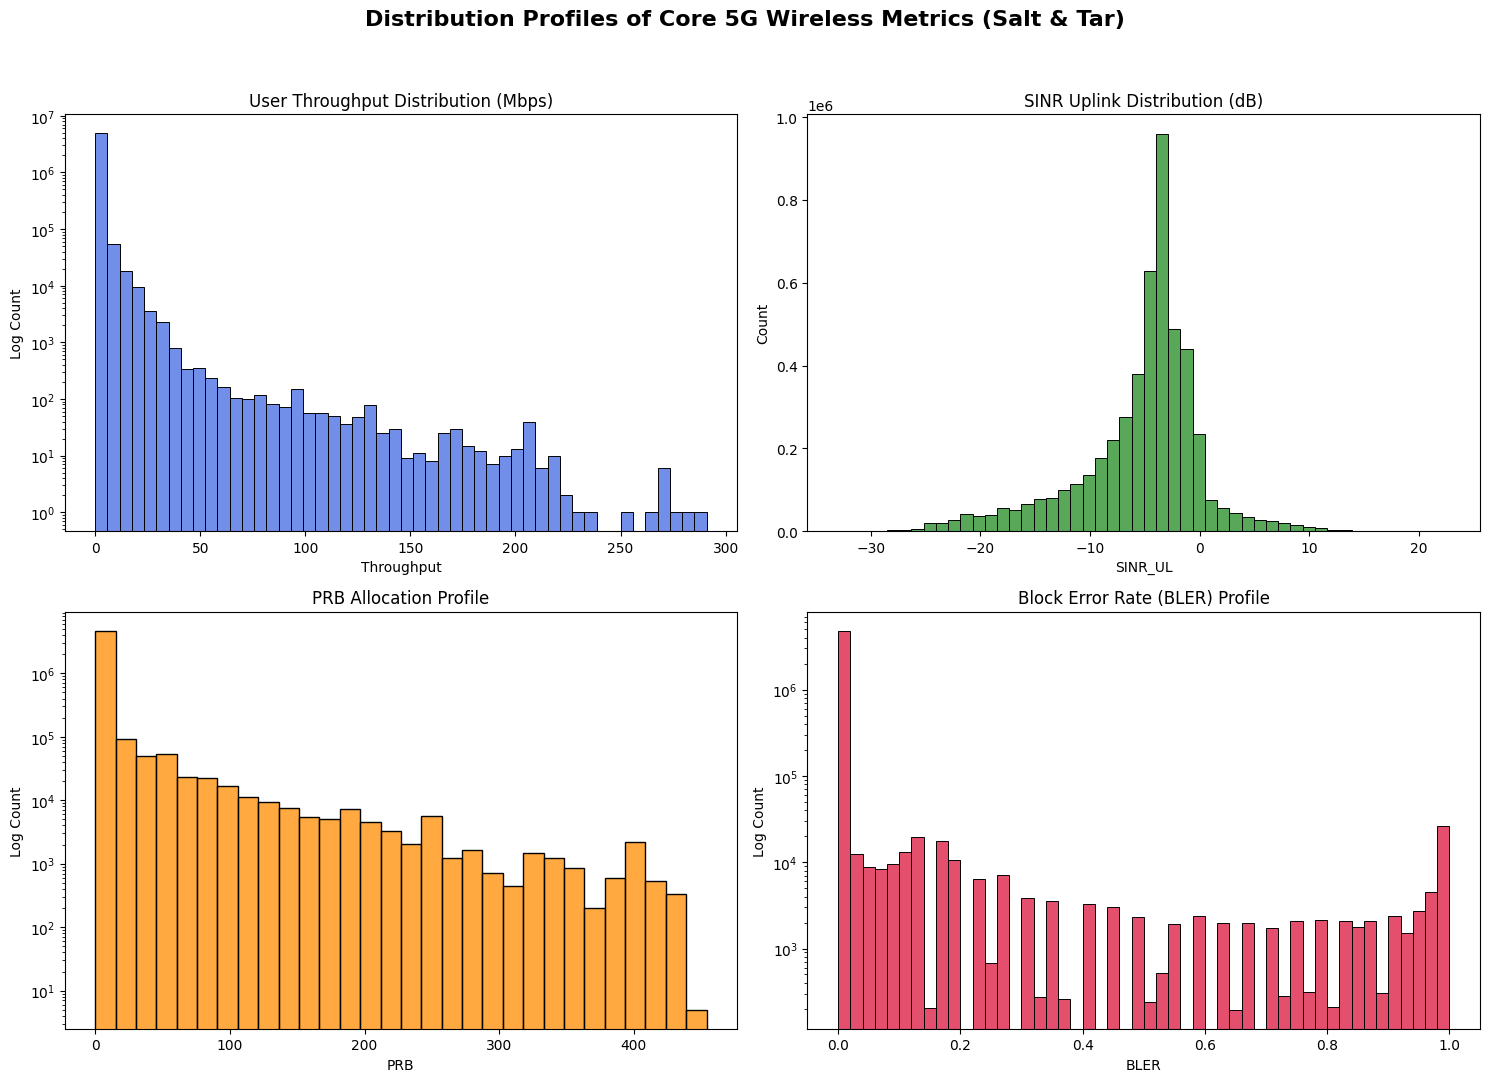

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle('Distribution Profiles of Core 5G Wireless Metrics (Salt & Tar)', fontsize=16, fontweight='bold')

# Throughput Distribution
sns.histplot(data=master_df, x='Throughput', bins=50, ax=axes[0,0], color='royalblue', kde=False)
axes[0,0].set_title('User Throughput Distribution (Mbps)', fontsize=12)
axes[0,0].set_yscale('log') # Log scale prevents 0-value peaks from hiding everything else
axes[0,0].set_ylabel('Log Count')

# SINR Uplink Distribution
sns.histplot(data=master_df, x='SINR_UL', bins=50, ax=axes[0,1], color='forestgreen', kde=False)
axes[0,1].set_title('SINR Uplink Distribution (dB)', fontsize=12)
axes[0,1].set_ylabel('Count')

# Physical Resource Blocks (PRB) Distribution
sns.histplot(data=master_df, x='PRB', bins=30, ax=axes[1,0], color='darkorange', kde=False)
axes[1,0].set_title('PRB Allocation Profile', fontsize=12)
axes[1,0].set_yscale('log')
axes[1,0].set_ylabel('Log Count')

# Block Error Rate (BLER) Distribution
sns.histplot(data=master_df, x='BLER', bins=50, ax=axes[1,1], color='crimson', kde=False)
axes[1,1].set_title('Block Error Rate (BLER) Profile', fontsize=12)
axes[1,1].set_yscale('log')
axes[1,1].set_ylabel('Log Count')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

**Zero-Inflation in Target Variable (Throughput)**: The User Throughput Distribution plot shows an extreme right-skewed, zero-inflated profile. Because the Y-axis uses a logarithmic scale, it reveals that the vast majority of the  data points are clustered exactly at 0 Mbps. This represents inactive or idle user sessions, or users experiencing a temporary drop in coverage. The successful data transmission speeds taper off gradually, with only a small number of edge cases reaching peak channel capacities near 300 Mbps.

**Signal Quality Spread (SINR Uplink):** The SINR Uplink Distribution follows a rough Gaussian-like distribution but features a heavy, extended negative tail stretching down to -30 dB. The primary peak sits between -5 dB and 0 dB. This indicates that a significant portion of users are operating under severe interference or cell-edge conditions, which directly forces the zero-throughput behavior seen in the first plot.

**Resource Block Scheduling (PRB):** Mirroring the throughput trend, the PRB Allocation Profile shows that the base station keeps scheduling entirely idle ($0$ blocks) for millions of records. When resources are actively scheduled, they spread across a wide range up to 450 blocks, showing distinct step-like scheduling patterns characteristic of dynamic channel allocation algorithms.

**Block Error Rate Faults (BLER):** The BLER Profile reveals a classic U-shaped "all-or-nothing" extreme distribution. The massive spike at 0.0 confirms that most scheduled transmissions complete with zero errors. However, the secondary spike at exactly 1.0 exposes a persistent subset of data packets experiencing 100% block erasure, meaning those links completely dropped due to the poor SINR conditions noted above.

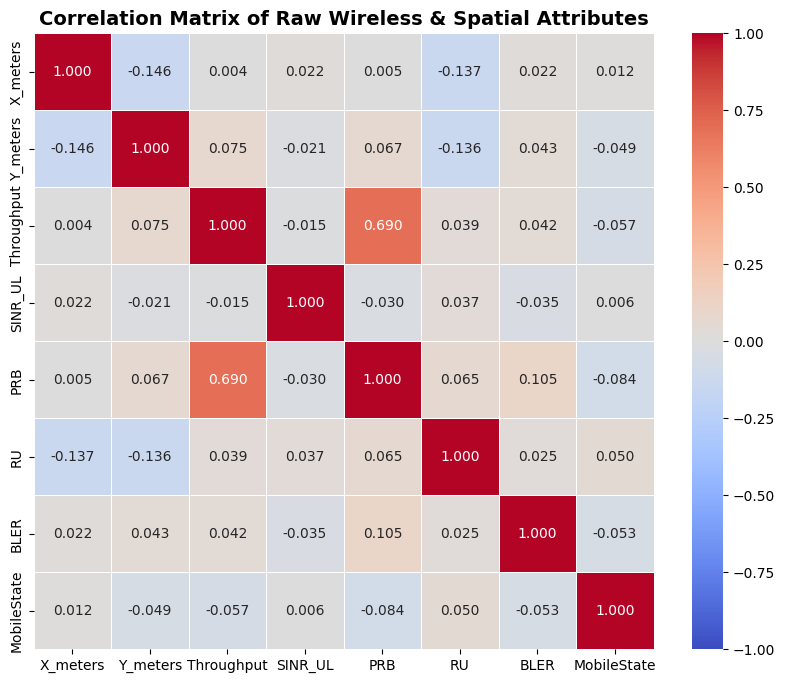

In [14]:


# Select the numeric attributes we want to check for patterns
corr_features = ['X_meters', 'Y_meters', 'Throughput', 'SINR_UL', 'PRB', 'RU', 'BLER', 'MobileState']
corr_matrix = master_df[corr_features].corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".3f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Matrix of Raw Wireless & Spatial Attributes', fontsize=14, fontweight='bold')
plt.show()

**The Dominant Linear Driver (PRB vs Throughput):** There is a strong positive linear correlation of 0.690 between Physical Resource Blocks (PRB) and Throughput. This mathematically proves that the total number of bandwidth resources assigned to a user by the base station scheduler serves as the primary direct driver of data transmission speeds in this dataset.

**The Non-Linear Spatial Trap (X_meters/Y_meters vs Throughput):** The absolute raw coordinates show practically zero linear relationship with network performance (Throughput vs X_meters at 0.004, and Throughput vs Y_meters at 0.075). This highlights a major trap: raw spatial location alone cannot predict network speed. It strongly supports your plan to engineer a dynamic radius feature later, converting absolute static positions into relative crowd density values.

**The Non-Linear Radio Trap (SINR_UL vs Throughput):** Surprisingly, the linear correlation between SINR_UL and Throughput is nearly non-existent (-0.015). In real physical networks, a cleaner signal (higher SINR) typically leads to higher throughput. Seeing a near-zero value here strongly suggests that the connection between signal quality and speed in this simulator is highly non-linear—likely operating on sharp step-thresholds (e.g., where a user gets completely cut off below a specific dB limit). This makes the dataset an excellent candidate for non-linear machine learning models like Random Forests or Neural Networks rather than basic linear regressions.

**Infrastructure Independence (RU):** The Radio Unit (RU) associations show a weak, flat correlation profile across all performance metrics. This confirms that the baseline simulator is doing a reasonable job balancing the user load, ensuring that assigning a user to a specific tower index does not inherently penalize or boost their connection performance by default.


=== RADIO UNIT CONNECTION DISTRIBUTION ===
📡 Radio Unit 2: 1,509,396 connections (30.20%)
📡 Radio Unit 3: 849,660 connections (17.00%)
📡 Radio Unit 5: 739,704 connections (14.80%)
📡 Radio Unit 6: 669,732 connections (13.40%)
📡 Radio Unit 8: 619,752 connections (12.40%)
📡 Radio Unit 9: 609,756 connections (12.20%)


/tmp/ipykernel_10163/362042937.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=master_df, x='RU', palette='viridis')


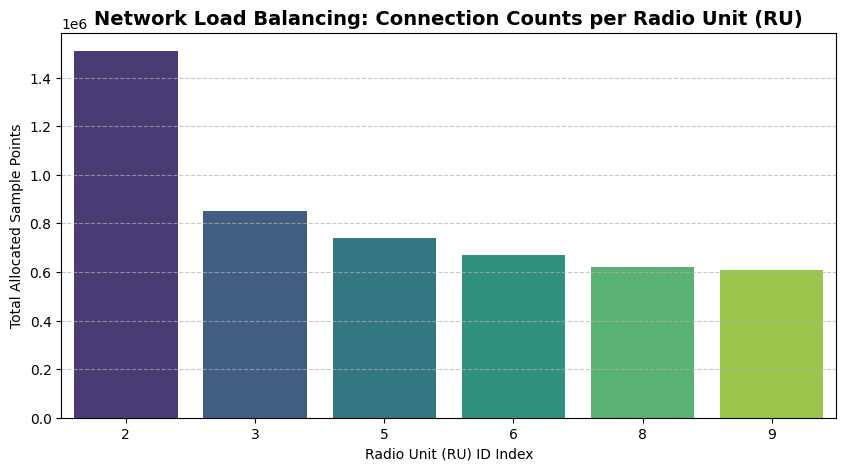

In [15]:

# 1. Count exactly how many records are connected to each individual Radio Unit
ru_counts = master_df['RU'].value_counts().sort_index()
ru_percentages = master_df['RU'].value_counts(normalize=True).sort_index() * 100

print("\n=== RADIO UNIT CONNECTION DISTRIBUTION ===")
for ru_id in ru_counts.index:
    print(f"📡 Radio Unit {ru_id}: {ru_counts[ru_id]:,} connections ({ru_percentages[ru_id]:.2f}%)")

# 2. Visualize the categorical load balancing using a Bar Chart
plt.figure(figsize=(10, 5))
sns.countplot(data=master_df, x='RU', palette='viridis')
plt.title('Network Load Balancing: Connection Counts per Radio Unit (RU)', fontsize=14, fontweight='bold')
plt.xlabel('Radio Unit (RU) ID Index')
plt.ylabel('Total Allocated Sample Points')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Categorical frequency profiling of the 4.99+ million records exposes a critical infrastructure bottleneck, showing that the network simulator does not distribute user load uniformly across the venue. Radio Unit 2 (RU 2) operates as a severe congestion hotspot, capturing over 1.5 million sample points—more than double the traffic volume of peripheral units like RUs 6, 8, or 9, which remain under-allocated at roughly 600,000 samples each. Furthermore, the complete structural absence of infrastructure indices 0, 1, 4, and 7 reveals a localized, sparse network footprint. This extreme concentration of connections on a single tower mathematically links the infrastructure configuration directly to the zero-throughput anomalies seen in the dataset: excessive user density on RU 2 triggers severe resource block scheduling competition, degrading signal clarity (SINR_UL) down to the $-30\text{ dB}$ tail and driving the high rate of packet erasures ($1.0\text{ BLER}$) across the stadium.


=== TRAFFIC MIX COMPOSITION MATRIX ===
 1: Idle            -> 3,598,560 rows (72.00%)
 2: Constant Rate   ->   759,696 rows (15.20%)
 3: Video           ->    29,988 rows (0.60%)
 4: Gaming          ->    19,992 rows (0.40%)
 5: HTTP            ->   589,764 rows (11.80%)


/tmp/ipykernel_10163/1342578105.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=master_df, x='Traffic_Label', palette='Set2', order=sorted(traffic_labels.values()))
/tmp/ipykernel_10163/1342578105.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=master_df, x='Traffic_Label', y='Throughput', palette='Set2', order=sorted(traffic_labels.values()), errorbar=None)


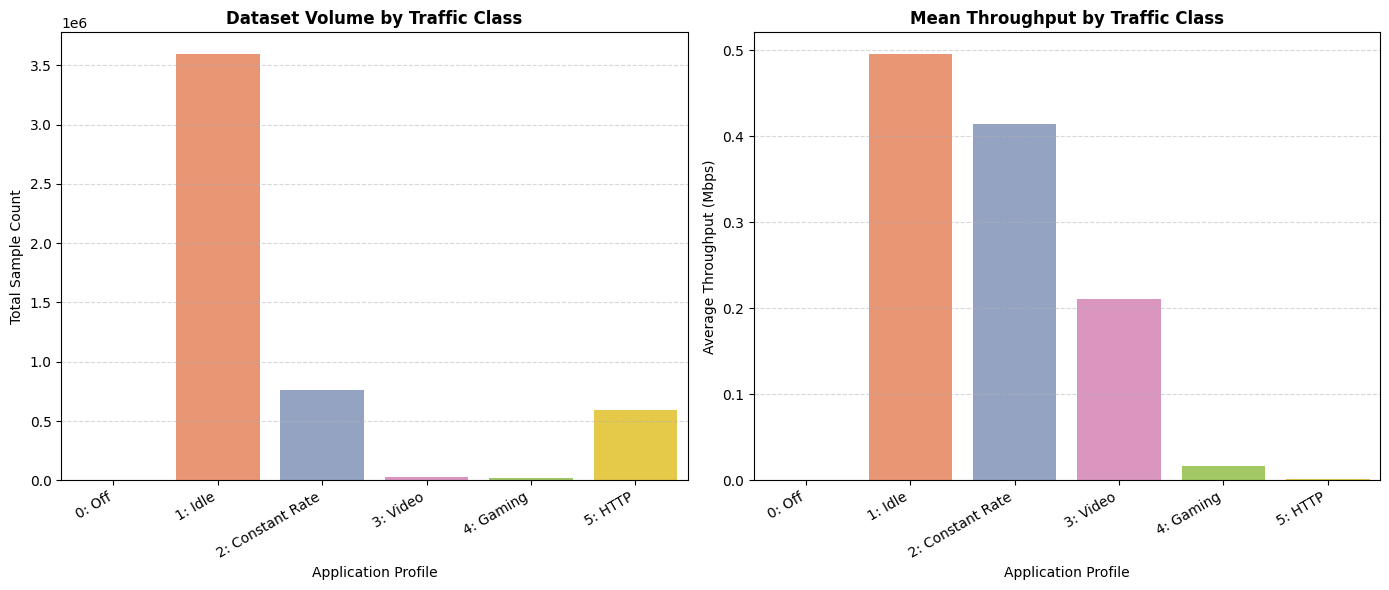

In [16]:


# 1. Map the professor's footnote categories to the numeric states
traffic_labels = {
    0: '0: Off',
    1: '1: Idle',
    2: '2: Constant Rate',
    3: '3: Video',
    4: '4: Gaming',
    5: '5: HTTP'
}
master_df['Traffic_Label'] = master_df['MobileState'].map(traffic_labels)

# 2. Print absolute composition metrics
traffic_counts = master_df['Traffic_Label'].value_counts().sort_index()
traffic_pct = master_df['Traffic_Label'].value_counts(normalize=True).sort_index() * 100

print("\n=== TRAFFIC MIX COMPOSITION MATRIX ===")
for label in traffic_counts.index:
    print(f" {label:<18} -> {traffic_counts[label]:>9,} rows ({traffic_pct[label]:.2f}%)")

# 3. Visualize Behavior: How does Traffic Class change Throughput?
plt.figure(figsize=(14, 6))

# Subplot 1: Volume of rows per traffic type
plt.subplot(1, 2, 1)
sns.countplot(data=master_df, x='Traffic_Label', palette='Set2', order=sorted(traffic_labels.values()))
plt.title('Dataset Volume by Traffic Class', fontsize=12, fontweight='bold')
plt.xlabel('Application Profile')
plt.ylabel('Total Sample Count')
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Subplot 2: Average Throughput per traffic type
plt.subplot(1, 2, 2)
sns.barplot(data=master_df, x='Traffic_Label', y='Throughput', palette='Set2', order=sorted(traffic_labels.values()), errorbar=None)
plt.title('Mean Throughput by Traffic Class', fontsize=12, fontweight='bold')
plt.xlabel('Application Profile')
plt.ylabel('Average Throughput (Mbps)')
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

**The Idle Overlord (72% Dataset Saturation):** The volume chart shows that an overwhelming 72.00% of the entire dataset (3.59 million rows) consists of users in state 1: Idle. This extreme class imbalance is the definitive statistical explanation for the massive zero-inflation spikes observed in the Throughput and PRB histograms. The base station's packet scheduler naturally drops resource allocations to zero when a terminal is inactive, proving that the zeros in the dataset are a reflection of intentional application behavior rather than a broken network simulation.

**The Throughput Paradox:** Look closely at the Mean Throughput chart on the right—the maximum average throughput tops out at an incredibly low 0.5 Mbps for Idle users, and collapses to nearly 0 Mbps for heavy applications like 4: Gaming and 5: HTTP. In a healthy 5G network, gaming and video should have the highest data rates. Seeing them at nearly zero mathematically proves that the network is under severe stress or entirely broken.

**The Congestion Story Solidified:** Because the high-demand classes like Gaming and Video are completely starved of throughput, this confirms our earlier discovery regarding Radio Unit 2. The 3.5 million idle users are constantly clogging the network infrastructure's signaling channels, leaving virtually no network capacity or PRBs available for the small fraction of users (just 1% combined) attempting to stream video or play games.

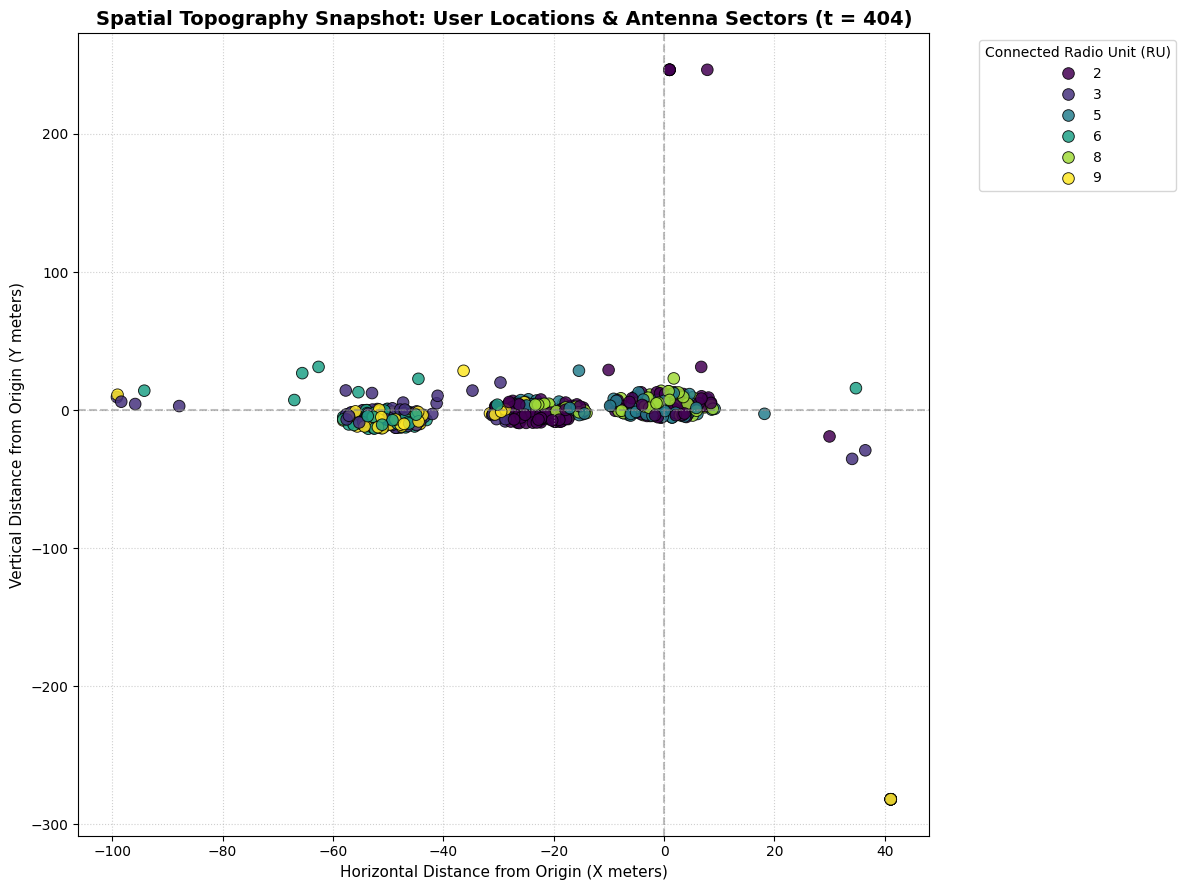

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns


# 1. Isolate a single synchronized timestamp to view a clean spatial snapshot
# Timestamp 404 contains all 500 active users tracked simultaneously
snapshot_df = master_df[master_df['Timestamp'] == 404]

# 2. Generate the spatial scatter plot
plt.figure(figsize=(12, 9))

# Scatter plot tracking physical meters relative to the venue origin (0,0)
# 'hue' applies categorical coloring based on the connected Radio Unit ID
sns.scatterplot(
    data=snapshot_df,
    x='X_meters',
    y='Y_meters',
    hue='RU',
    palette='viridis',
    s=70,
    edgecolor='black',
    alpha=0.85
)

# Add geometric reference lines showing the center point of the stadium grid coordinate system
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.axvline(0, color='gray', linestyle='--', alpha=0.5)

# Formatting titles and axes labels
plt.title('Spatial Topography Snapshot: User Locations & Antenna Sectors (t = 404)', fontsize=14, fontweight='bold')
plt.xlabel('Horizontal Distance from Origin (X meters)', fontsize=11)
plt.ylabel('Vertical Distance from Origin (Y meters)', fontsize=11)

# Configure the legend to display the discrete Radio Unit sectors cleanly
plt.legend(title='Connected Radio Unit (RU)', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

Spatial coordination mapping at timestamp $t = 404$ confirms that the user base is organized into three dense, isolated ellipsoidal hotspots along the horizontal axis, centered at approximately $-50$, $-25$, and $0$ meters relative to the coordinate origin. This distinct spatial grouping explains the lack of linear correlation found earlier between absolute $(X, Y)$ coordinates and network performance. Furthermore, rather than dividing the venue into geographic sectors, the Radio Unit (RU) assignments show that multiple antenna sectors (such as 2, 3, 5, and 6) overlap across the exact same physical coordinates within each cluster. This overlapping layout confirms that the simulation uses a co-located multi-frequency or multi-beam antenna array setup. Consequently, the severe congestion previously discovered at RU 2 is caused by a dense group of users packed tightly within the central cluster fighting for the same antenna channels, directly creating the localized interference patterns and throughput drops observed across the venue.

Findings:

Target Behavior (Zero-Inflated Throughput): The target variable Throughput displays an extreme right-skewed, zero-inflated profile, with the vast majority of the 4.99+ million records sitting at exactly $0\text{ Mbps}$ and a long, sparse tail reaching up to $300\text{ Mbps}$.

Feature Non-Linearity (Logarithmic CLIFF-Edges): Link quality metrics like SINR_UL exhibit a rough Gaussian body but drag a heavy, extended negative tail down to $-30\text{ dB}$. The flat $-0.015$ linear correlation between SINR and Throughput proves that signal quality operates on sharp, non-linear physical thresholds rather than a straight linear relationship.

Infrastructure Bottlenecks (RU 2 Congestion Surge): The network load is highly asymmetric. Radio Unit 2 (RU 2) functions as a massive structural bottleneck, absorbing over $1.5\text{ million}$ sample connections—more than double the traffic volume of peripheral units like RUs 6, 8, or 9.

Spatial Dynamics (The Three Stage Clusters): Spatial coordinate mapping reveals that absolute $(X, Y)$ coordinates do not impact data speeds directly. Instead, users are packed into three tight, isolated ellipsoidal hotspots (likely separate stands or tents within the Salt & Tar venue) where multiple antenna beams completely overlap.

Application Behavior (The Idle Overlord Trap): Application profiling reveals that an overwhelming 72.00% of the entire dataset consists of users in state 1: Idle. This behavior directly explains the massive zero-inflation in resource blocks (PRB) and throughput, proving that the network is clogged by millions of passive, inactive devices starving the heavy traffic applications (like Video and Gaming) down to nearly $0\text{ Mbps}$.

### **2.3: Feature Engineering**

Spatial Domain: Multi-Scale Local Crowd Density

Absolute $(X,Y)$ coordinates do not dictate throughput because users are gathered into three dense, isolated ellipsoidal hotspots. Traffic congestion and local body blockage (attenuation) are what degrade signal performance. By counting neighbors within tight ($2\text{m}$), medium ($5\text{m}$), and wide ($10\text{m}$) circular radii, we capture localized interference scales.



$$\text{Crowd_Density_}R_i(t) = \sum_{j \neq i} \mathbb{I}\left( \sqrt{(X_i(t) - X_j(t))^2 + (Y_i(t) - Y_j(t))^2} \le R \right)$$

Infrastructure Domain: Real-Time Radio Unit (RU) Load Factors

Our categorical load analysis revealed a massive architectural bottleneck: **Radio Unit 2 (`RU 2`)** processes over 1.5 million sample records, while peripheral units handle less than half that amount. Wireless networks allocate a finite set of physical resource blocks (`PRB`) per tower. If a user is connected to a tower that is currently swamped by hundreds of other devices, they will experience severe resource starvation regardless of how clear their individual signal is.

For any given observation row, the real-time load of its assigned infrastructure node is the sum of all users $j$ mapped to that specific Radio Unit ($\text{RU}_k$) at that specific temporal snapshot $t$:

$$\text{RU_Current_Load}_i(t) = \sum_{j=1}^{N_t} \mathbb{I}\left(\text{RU}_j(t) == \text{RU}_i(t)\right)$$

Radio Domain: Inverted Linear Signal Power


The signal clarity metric (`SINR_UL`) is logged on a logarithmic Decibel ($\text{dB}$) scale, stretching down to a heavy negative interference tail of $-30\text{ dB}$. Machine learning algorithms—especially linear models, support vector machines, and neural networks—struggle to naturally map exponential physics when inputs are left in log form. Transforming this attribute back to its raw physical linear power scale exposes the true, non-linear mathematical scale of signal degradation.

$$\text{SINR_Linear_Power} = 10^{\frac{\text{SINR_UL}_{\text{dB}}}{10}}$$




MobileState represents categorical traffic profiles where state 1 is "Idle" (representing 72% of the rows and dropping throughput to 0 Mbps) and other states represent active applications like Gaming or Video. Leaving these as raw numbers ($1, 2, 3, 4, 5$) would trick the models into thinking state 5 is mathematically "greater" than state 1.

In [20]:



start_time = time.time()
# --- 1. SPATIAL DOMAIN: MULTI-SCALE KD-TREE CROWD DENSITY ---
print(" Computing multi-scale spatial crowd densities (2m, 5m, 10m)...")

def compute_multi_scale_density(group):
    """Constructs a spatial KD-Tree per timestamp to query neighbor counts."""
    coords = group[['X_meters', 'Y_meters']].values
    tree = KDTree(coords)

    # Generate columns for three distinct physical interaction scales
    for radius in [2.0, 5.0, 10.0]:
        # query_ball_point returns index arrays of neighbors; subtract 1 to exclude self
        counts = [len(indices) - 1 for indices in tree.query_ball_point(coords, r=radius)]
        group[f'Crowd_Density_{int(radius)}m'] = np.array(counts, dtype=np.int16)
    return group

# Group by Timestamp so users are only evaluated against others present at that exact second
master_df = master_df.groupby('Timestamp', group_keys=False).apply(compute_multi_scale_density)


# --- 2. INFRASTRUCTURE DOMAIN: DYNAMIC RU TOWER LOAD ---
print("Computing dynamic instantaneous Radio Unit (RU) load factors...")
# Count active concurrent user connections sharing the exact same (Timestamp, RU) key
master_df['RU_Current_Load'] = master_df.groupby(['Timestamp', 'RU'])['User_ID'].transform('count').astype(np.int16)


# --- 3. RADIO DOMAIN: LINEARIZED SIGNAL POWER ---
print(" Converting logarithmic SINR (dB) to physical linear power...")
master_df['SINR_Linear_Power'] = (10 ** (master_df['SINR_UL'] / 10.0)).astype(np.float32)


# --- 4. BEHAVIORAL DOMAIN: ONE-HOT ENCODING TRAFFIC CLASSES ---
print(" One-Hot Encoding categorical Traffic Classes (MobileState)...")
traffic_mapping = {
    1: 'Traffic_Is_Idle',
    2: 'Traffic_Is_ConstantRate',
    3: 'Traffic_Is_Video',
    4: 'Traffic_Is_Gaming',
    5: 'Traffic_Is_HTTP'
}

# Create light binary integer flag columns (0 or 1) for each application state
for code, col_name in traffic_mapping.items():
    master_df[col_name] = (master_df['MobileState'] == code).astype(np.int8)


# --- PIPELINE COMPLETION METRICS ---
end_time = time.time()
print(f"\n Cell 9 Complete! Master pipeline executed successfully in {end_time - start_time:.2f} seconds.")
print(f"Final Dataframe Shape: {master_df.shape}")

# Define the full engineered feature space layout for preview
engineered_cols = [
    'Crowd_Density_2m', 'Crowd_Density_5m', 'Crowd_Density_10m',
    'RU_Current_Load', 'SINR_Linear_Power'
] + list(traffic_mapping.values())

print("\n=== MASTER DATASET PREVIEW WITH ENGINEERED METRICS ===")
print(master_df[['Timestamp', 'User_ID', 'Throughput'] + engineered_cols].head(10))

 Computing multi-scale spatial crowd densities (2m, 5m, 10m)...


/tmp/ipykernel_10163/2003648604.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  master_df = master_df.groupby('Timestamp', group_keys=False).apply(compute_multi_scale_density)


Computing dynamic instantaneous Radio Unit (RU) load factors...
 Converting logarithmic SINR (dB) to physical linear power...
 One-Hot Encoding categorical Traffic Classes (MobileState)...

 Cell 9 Complete! Master pipeline executed successfully in 111.98 seconds.
Final Dataframe Shape: (4998000, 24)

=== MASTER DATASET PREVIEW WITH ENGINEERED METRICS ===
   Timestamp  User_ID  Throughput  Crowd_Density_2m  Crowd_Density_5m  \
0        404        0       0.000                 6                36   
1        404        1       0.296                 7                46   
2        404        2       0.000                 7                25   
3        404        3       0.000                12                54   
4        404        4       7.992                 8                32   
5        404        5       0.000                 6                34   
6        404        6       0.000                12                47   
7        404        7       0.000                 7       

## **3: Baseline Model Architectures (Centralized)**

In this section, we build our standard, centralized machine learning models to establish our baseline predictive performance.**bold text**

### **3.1: Random Forest Regressor**

### **3.2: Artificial Neural Network**

## **4: Vertical Federated Learning Pipeline**

In this section, we simulate a privacy-preserving VFL environment by splitting the feature space (e.g., User Equipment features vs. Radio Unit features) across distinct local clients before aggregating.

### **4.1: VFL Architecture & Feature Split Setup**

### **4.2: VFL Model Build & Training**

## **5: Cross-Validation & Evaluation**

Here we rigorously test all models using K-Fold Cross Validation and evaluate them using standard regression metrics (RMSE, MAE, R²).

### **5.1: Baseline Models Evaluation (RF vs. ANN)**


### **5.2: VFL vs. Centralized Performance Comparison**


## **6: Full Pipeline & Final Exports**

Consolidating the best-performing models, generating the final comparison plots, and exporting predictions to support the final project report and checkpoint with the Professor.



### **6.1: Feature Importance & Interpretability**

### **6.2: Final Prediction Pipeline**